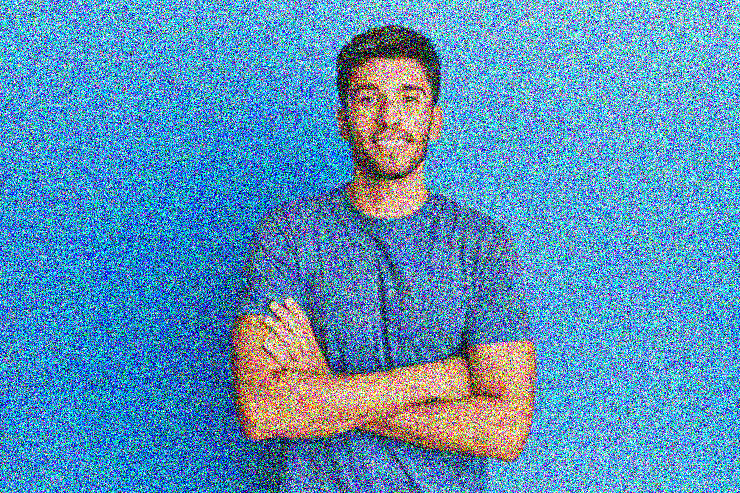

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import torchvision

import requests
from io import BytesIO
from PIL import Image
img = Image.open(BytesIO(requests.get("https://img.freepik.com/free-photo/young-handsome-man-wearing-casual-tshirt-blue-background-happy-face-smiling-with-crossed-arms-looking-camera-positive-person_839833-12963.jpg?semt=ais_hybrid&w=740&q=80").content))

to_tensor = torchvision.transforms.ToTensor()
to_image = torchvision.transforms.ToPILImage()

noise_scale = 0.4

img_t = to_tensor(img)
noise = torch.randn_like(img_t) * noise_scale
noised = torch.clip(img_t + noise, 0, 1)
to_image(noised)

In [2]:
class TimeProj(nn.Module):
  def __init__(self, d_in: int, d_out: int):
    super().__init__()
    self.d_in = d_in
    self.d_out = d_out

    self.l1 = nn.Linear(d_in, d_out)
    self.act = nn.SiLU()
    self.l2 = nn.Linear(d_out, d_out)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.l2(self.act(self.l1(x)))

class MyNet(nn.Module):
  def __init__(self, num_channels: int, num_downscales: int, kernel_size: int, stride: int, device: torch.device, img_size: int = 512, emb_dim: int = 128):
    super().__init__()
    self.num_channels = num_channels
    self.num_downscales = num_downscales
    self.kernel_size = kernel_size
    self.stride = stride
    self.device = device
    
    self.downconvs = nn.ModuleList([nn.Conv2d(num_channels, num_channels, kernel_size, stride) for _ in range(num_downscales)])
    self.upconvs = nn.ModuleList([nn.ConvTranspose2d(num_channels, num_channels, kernel_size, stride) for _ in range(num_downscales)])
    self.out_proj = nn.Conv2d(num_channels, num_channels, 1, 1)

    self.time_emb = torch.empty(emb_dim, device=device)

    for i in range(emb_dim):
      self.time_emb[i] = 10000**(2 * i / (emb_dim))

    self.time_proj = TimeProj(emb_dim, img_size)

  def forward(self, x: torch.Tensor, sigmas: torch.Tensor) -> torch.Tensor:
    B, channels, img_size, _ = x.size()

    embeddings = torch.einsum("b, d -> b d", sigmas, self.time_emb)


    odds = embeddings[:, 1::2]
    evens = embeddings[:, ::2]

    embeddings = torch.cat((torch.cos(odds), torch.sin(evens)), dim=-2).view(B, -1)

    x = x + self.time_proj(embeddings).unsqueeze(1).unsqueeze(-1)

    residuals = [x]
    for downlayer in self.downconvs:
      x = downlayer(x)
      residuals.insert(0, x)
      x = F.silu(x)

    for uplayer, residual in zip(self.upconvs, residuals):
      x = uplayer(x + residual)

      x = F.silu(x)

    return self.out_proj(x)



mynet = MyNet(3, 4, 2, 2, torch.device("cpu"))
mynet(torch.randn(2, 3, 512, 512), torch.randn(2)).size()


torch.Size([2, 3, 512, 512])

In [43]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
torch.set_float32_matmul_precision("high")

num_steps = 1000
bsz = 128

noise_min = 0.01
noise_max = 1.0

img_size = 512
n_channels = 3
num_downscales = 4
kernel_size = 2
stride = 2
d_model = 128

lr = 0.1

model = MyNet(
    num_channels=n_channels,
    num_downscales=num_downscales,
    kernel_size=kernel_size,
    stride=stride,
    emb_dim=d_model,
    device=device,
)

print("params:", sum(p.numel() for p in model.parameters()))

optim = torch.optim.AdamW(model.parameters(), lr=lr)

img_resized = img.resize((img_size, img_size))
sample = to_tensor(img_resized).to(device)

for step in range(num_steps):
  sigmas = torch.clamp(torch.rand(bsz) * noise_max, noise_min, noise_max)

  with torch.no_grad():
    noises = torch.randn(bsz, n_channels, img_size, img_size, device=device)
    xs = torch.clamp(sample.unsqueeze(0) + torch.einsum("b n x y, b -> b n x y", noises, sigmas), 0, 1)
    ys = torch.clamp(-torch.einsum("b n x y, b -> b n x y", noises, 1 / sigmas), -1, 1)
  y_hat = model(xs, sigmas)

  loss = 0.5 * ((ys - y_hat)**2).mean() + (1 / y_hat.std())

  if step % 100 == 0:
    print(f"step {step} | loss {loss.item():.4f}")
    print(xs.mean().item(), xs.std().item(), ys.mean().item(), ys.std().item(), y_hat.mean().item(), y_hat.std().item())

  optim.zero_grad()
  loss.backward()
  optim.step()


params: 329028
step 0 | loss 10.2517
0.5505760908126831 0.3693903386592865 6.637669866904616e-05 0.8667532801628113 -0.04079029709100723 0.10131632536649704
step 100 | loss 1.8913
0.550690770149231 0.36933642625808716 -0.00012611321290023625 0.8673274517059326 0.04919618368148804 1.1006122827529907
step 200 | loss 1.8652
0.547870397567749 0.37744683027267456 -7.026988896541297e-05 0.8527257442474365 0.009127079509198666 1.0321968793869019
step 300 | loss 1.8776
0.5509730577468872 0.3676982522010803 0.00010406289948150516 0.8694744110107422 -0.0015313427429646254 1.0021202564239502
step 400 | loss 1.8636
0.54747474193573 0.3783779442310333 -3.410803037695587e-05 0.8505924344062805 0.008915740065276623 0.9612466096878052
step 500 | loss 1.8621
0.5464417934417725 0.38167524337768555 -1.3614611816592515e-05 0.8458566665649414 0.031253740191459656 0.9454257488250732
step 600 | loss 1.8865
0.5514496564865112 0.3664039969444275 -2.53829057328403e-06 0.8735770583152771 -0.051096733659505844 1.

KeyboardInterrupt: 

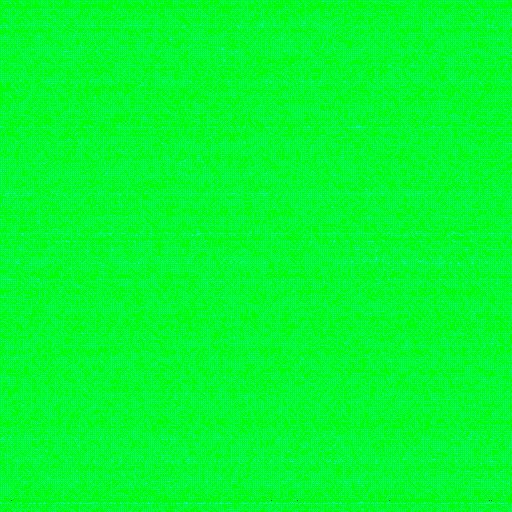

In [44]:
alpha = 0.5
x = torch.randn(1, n_channels, img_size, img_size)


for t in range(300):
  sigma = 300 * noise_max / (t + 1) ** 2
  predicted_noise = model(x, sigmas=torch.tensor([sigma]))
  x = x + alpha * predicted_noise + (2 * alpha)**0.5 * torch.randn(1, n_channels, img_size, img_size)

to_image(torch.clip(x.squeeze(0), 0, 1))

Note:

i think i am doing things wrong.

i am doing MSE on the model output and noise directly.

should it instead be the on the scores?